#### Adaline Loss vs Logistic Loss

### 1. True Class is Positive (Left Graph)
* **Logistic Regression:** Rewards the model smoothly as $z$ becomes more positive (highly confident and correct). It only severely punishes the model when $z$ goes deep into the negative territory.
* **Adaline:** Wants the output to be *exactly* 1. If $z$ goes past 1, the penalty aggressively curves upwards.

### 2. True Class is Negative (Right Graph)
* **Logistic Regression:** Rewards the model smoothly as $z$ becomes more negative (highly confident that it's class 0). It severely punishes the model if $z$ becomes highly positive.
* **Adaline:** Wants the output to be *exactly* 0. If $z$ goes past 0 into deeper negative territory (e.g., $z = -4$), the loss explodes again, penalizing the model for being "too correct" in the negative direction.

<>:50: SyntaxWarning: invalid escape sequence '\i'
<>:50: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_637/429623469.py:50: SyntaxWarning: invalid escape sequence '\i'
  plt.suptitle('Comparison of Loss Functions (Using $y \in \{0, 1\}$ for Both)', fontsize=16)


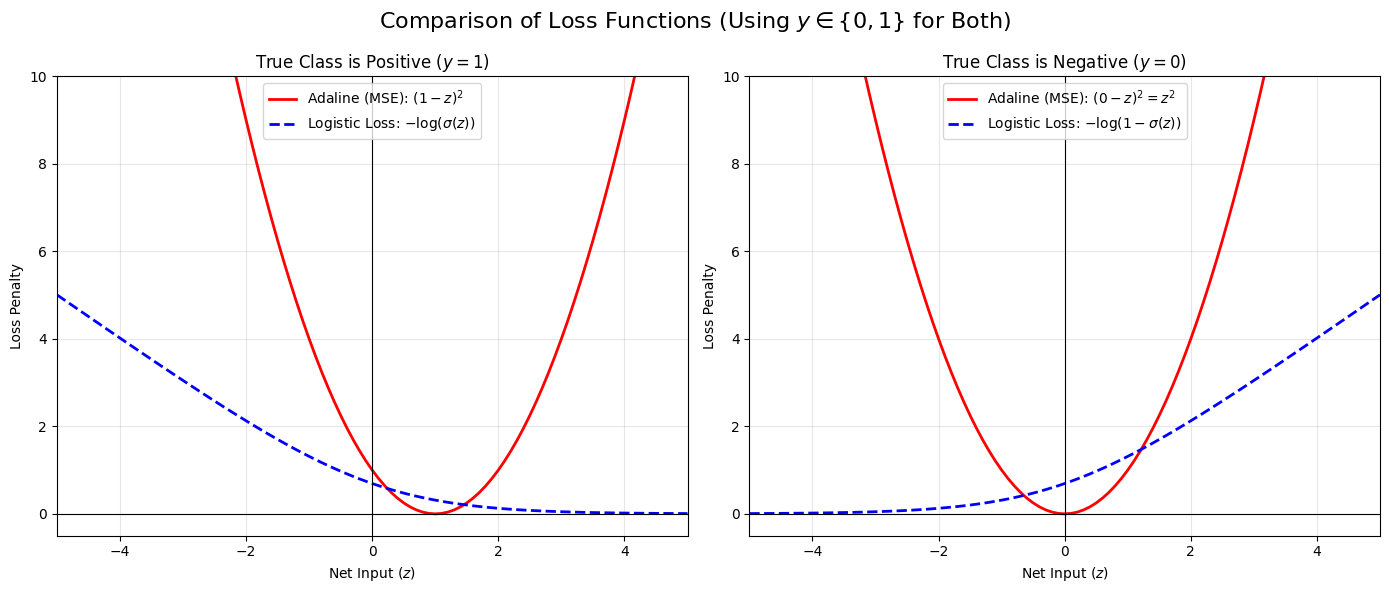

In [115]:
# @title
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Range of net input (z) from -5 to 5
z = np.arange(-5, 5.1, 0.1)

# --- Losses for True Positive Class ---
# Target is y=1 for both models
mse_loss_pos = (1 - z)**2
log_loss_pos = -np.log(sigmoid(z))

# --- Losses for True Negative Class ---
# Target is y=0 for both models
mse_loss_neg = (0 - z)**2
log_loss_neg = -np.log(1 - sigmoid(z))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Positive Class
ax1.plot(z, mse_loss_pos, label='Adaline (MSE): $(1 - z)^2$', linewidth=2, color='red')
ax1.plot(z, log_loss_pos, label='Logistic Loss: $-\\log(\\sigma(z))$', linewidth=2, color='blue', linestyle='--')
ax1.set_title('True Class is Positive ($y=1$)')
ax1.set_xlabel('Net Input ($z$)')
ax1.set_ylabel('Loss Penalty')
ax1.set_ylim(-0.5, 10)
ax1.set_xlim(-5, 5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.legend(loc='upper center')
ax1.grid(True, alpha=0.3)

# Plot 2: Negative Class
ax2.plot(z, mse_loss_neg, label='Adaline (MSE): $(0 - z)^2 = z^2$', linewidth=2, color='red')
ax2.plot(z, log_loss_neg, label='Logistic Loss: $-\\log(1 - \\sigma(z))$', linewidth=2, color='blue', linestyle='--')
ax2.set_title('True Class is Negative ($y=0$)')
ax2.set_xlabel('Net Input ($z$)')
ax2.set_ylabel('Loss Penalty')
ax2.set_ylim(-0.5, 10)
ax2.set_xlim(-5, 5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)

plt.suptitle('Comparison of Loss Functions (Using $y \in \{0, 1\}$ for Both)', fontsize=16)
plt.tight_layout()
plt.show()

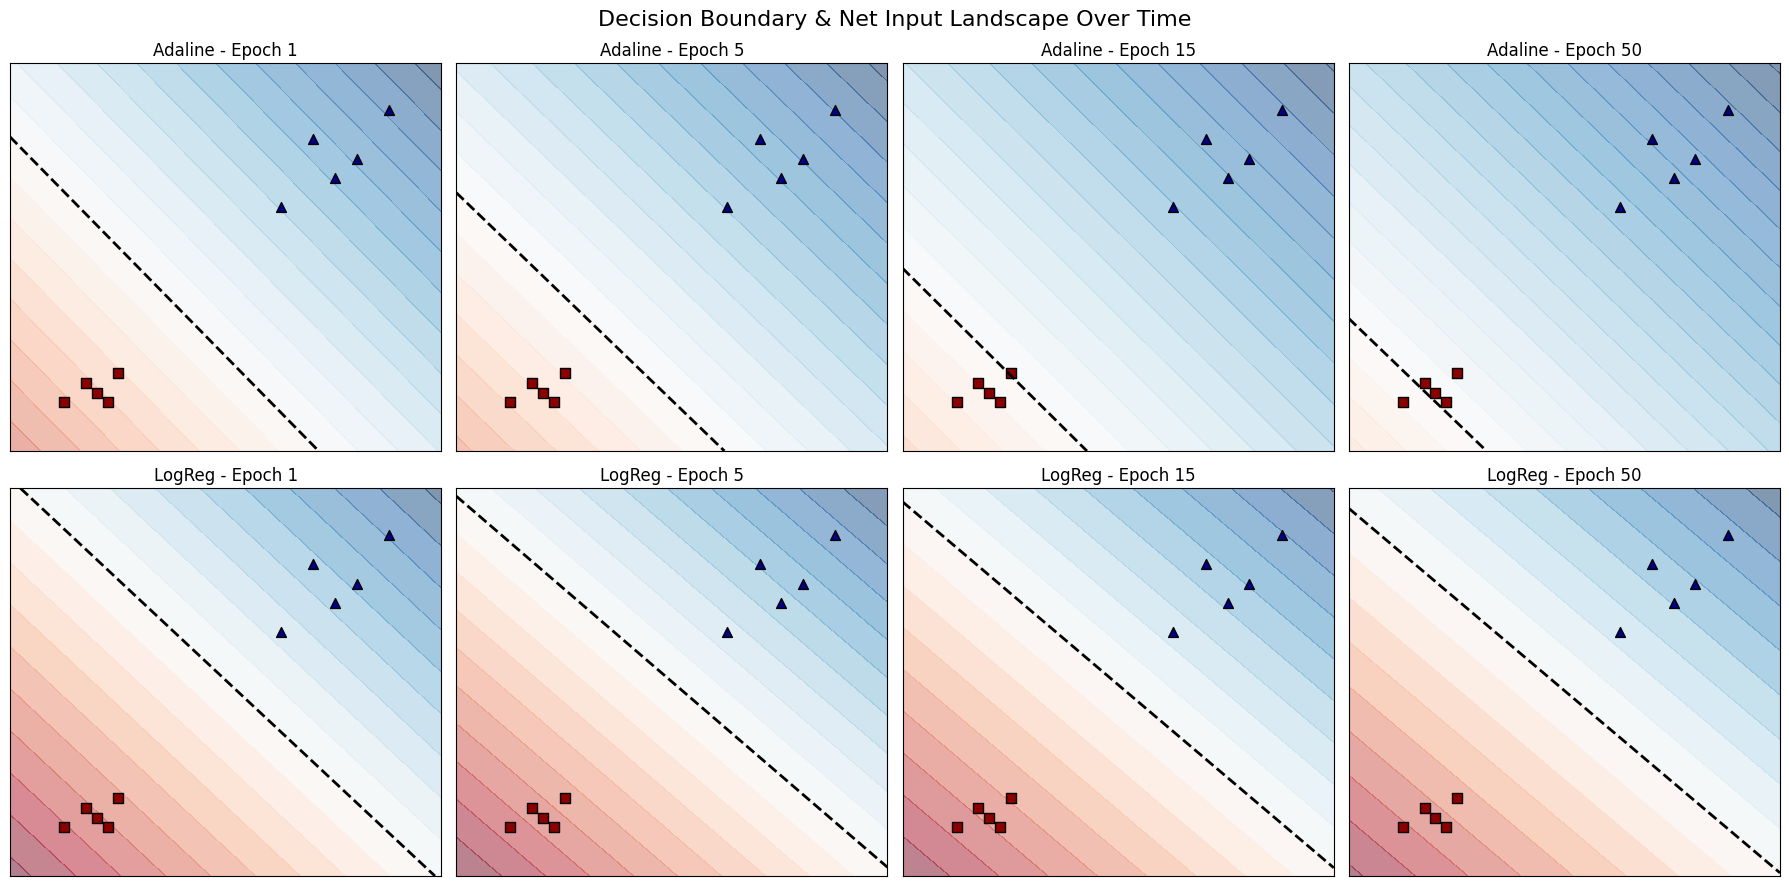

In [116]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset
X = np.array([
    [-1.5, -1.5], [-1.2, -1.4], [-1.0, -1.2], [-1.3, -1.3], [-1.1, -1.5], # True Class 0
    [0.5, 0.5], [1.0, 0.8], [0.8, 1.2], [1.2, 1.0], [1.5, 1.5]            # True Class 1
])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# 2. Helper Functions
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

def plot_net_input_boundary(ax, X, y, w, b, title):
    # Setup a dense grid to calculate the background contour
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                           np.arange(x2_min, x2_max, 0.02))

    # Calculate Net Input (z) for every single point on that grid
    Z = w[0] * xx1 + w[1] * xx2 + b

    # Plot background contour (Red = Negative z, Blue = Positive z)
    vmax = max(abs(Z.min()), abs(Z.max())) # Keep colors symmetric around 0
    contour = ax.contourf(xx1, xx2, Z, alpha=0.5, cmap='RdBu', levels=20, vmin=-vmax, vmax=vmax)

    # Plot the exact decision boundary where Net Input z = 0
    ax.contour(xx1, xx2, Z, levels=[0], colors='black', linewidths=2, linestyles='--')

    # Plot the actual data points (True Class)
    ax.scatter(X[y==0, 0], X[y==0, 1], color='darkred', marker='s', edgecolor='black', s=50, label='True Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='darkblue', marker='^', edgecolor='black', s=50, label='True Class 1')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return contour

def train_and_capture(X, y, algo='logistic', epochs=50, lr=0.1, capture_epochs=[1, 5, 15, 50]):
    np.random.seed(42) # Start both models from the exact same random weights
    w = np.random.normal(loc=0.0, scale=0.01, size=X.shape[1])
    b = np.float64(0.)
    history = {}

    for epoch in range(1, epochs + 1):
        z = np.dot(X, w) + b

        if algo == 'logistic':
            output = sigmoid(z)
        else:
            output = z

        errors = (y - output)
        w += lr * X.T.dot(errors) / len(y)
        b += lr * errors.mean()

        if epoch in capture_epochs:
            history[epoch] = (w.copy(), b.copy())

    return history

# 3. Execution and Plotting
epochs_to_plot = [1, 5, 15, 50]
history_log = train_and_capture(X, y, algo='logistic', epochs=50)
history_ada = train_and_capture(X, y, algo='adaline', epochs=50)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, epoch in enumerate(epochs_to_plot):
    # Plot Adaline (Top Row)
    w_ada, b_ada = history_ada[epoch]
    plot_net_input_boundary(axes[0, i], X, y, w_ada, b_ada, f"Adaline - Epoch {epoch}")

    # Plot Logistic Regression (Bottom Row)
    w_log, b_log = history_log[epoch]
    plot_net_input_boundary(axes[1, i], X, y, w_log, b_log, f"LogReg - Epoch {epoch}")

plt.suptitle("Decision Boundary & Net Input Landscape Over Time", fontsize=16)
plt.tight_layout()
plt.show()

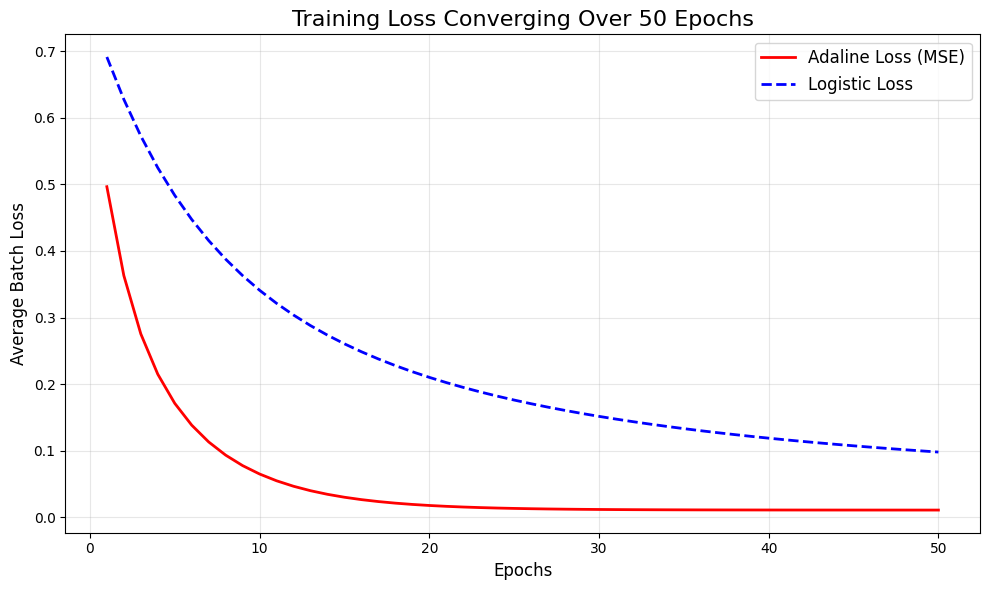

In [117]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset
X = np.array([
    [-1.5, -1.5], [-1.2, -1.4], [-1.0, -1.2], [-1.3, -1.3], [-1.1, -1.5], # True Class 0
    [0.5, 0.5], [1.0, 0.8], [0.8, 1.2], [1.2, 1.0], [1.5, 1.5]            # True Class 1
])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

def train_and_get_losses(X, y, algo='logistic', epochs=50, lr=0.1):
    np.random.seed(42)
    w = np.random.normal(loc=0.0, scale=0.01, size=X.shape[1])
    b = np.float64(0.)
    losses = []

    for epoch in range(1, epochs + 1):
        z = np.dot(X, w) + b

        if algo == 'logistic':
            output = sigmoid(z)
            # Logistic Loss calculation (adding a tiny epsilon to prevent log(0) errors)
            epsilon = 1e-5
            loss = -np.mean(y * np.log(output + epsilon) + (1 - y) * np.log(1 - output + epsilon))
        else:
            output = z
            # Mean Squared Error (MSE) calculation
            loss = np.mean((y - output)**2)

        losses.append(loss)

        # Weight updates
        errors = (y - output)
        w += lr * X.T.dot(errors) / len(y)
        b += lr * errors.mean()

    return losses

# 2. Get the loss history for both models
epochs = 50
losses_log = train_and_get_losses(X, y, algo='logistic', epochs=epochs)
losses_ada = train_and_get_losses(X, y, algo='adaline', epochs=epochs)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses_ada, label='Adaline Loss (MSE)', color='red', linewidth=2)
plt.plot(range(1, epochs + 1), losses_log, label='Logistic Loss', color='blue', linewidth=2, linestyle='--')

plt.title('Training Loss Converging Over 50 Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Average Batch Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In this specific visualization, **Logistic Regression** performed noticeably better, even though both models successfully separated the two classes by Epoch 50.

The superiority of Logistic Regression here isn't about raw accuracy, but rather about the **quality and stability of the decision boundary**.

Here is what the visual evidence shows:

**1. A Safer Decision Boundary**
* **Adaline (Top Row):** Look at the dashed line in Epoch 50. It sits uncomfortably close to the red squares. If you added a new, slightly varied red data point to this dataset, Adaline would likely misclassify it because it left almost no margin for error.
* **Logistic Regression (Middle Row):** By Epoch 50, its decision boundary has settled perfectly in the middle of the "street" between the red squares and blue triangles. It maximizes the safety gap between the two groups, making it a much more robust model for future, unseen data.

**2. Higher Confidence (The Background Colors)**
* **Adaline:** The background contour colors at Epoch 50 are very pale and washed out. Because Adaline uses Mean Squared Error, it heavily penalizes the weights if the net input strays too far past the target numbers. It practically forces the model to be "unsure" to avoid the penalty for being "too correct."
* **Logistic Regression:** The background colors are rich, deep red and deep blue. Because Logistic Loss rewards extreme confidence, the model allows the weights to grow, pushing the data points deep into their respective highly confident probability zones.

**3. The Loss Curve Evolution**
* **Adaline (Red Line):** The loss drops rapidly but then completely flattens out around Epoch 15. It stops learning effectively because it's impossible to draw a single line that makes the net input exactly perfect for every point simultaneously.
* **Logistic Regression (Blue Line):** The loss curve is smoother and continues to trend downward even at Epoch 50. It is constantly fine-tuning the weights to squeeze out an extra fraction of a percent of probability, resulting in that perfectly centered decision boundary.